# 模型模块演示 (Models Module)

本notebook演示hscredit库中模型模块的全部功能，包含多种风控模型和评分卡。

**更新内容**: ScoreCard 现已继承 StandardScoreTransformer，支持更多评分转换功能。

In [1]:
# 添加项目路径
import sys
import os
sys.path.append('../')

# 初始化设置
from hscredit.utils import init_setting
init_setting(seed=42)

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

# 加载数据
data_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/hscredit.xlsx'
df = pd.read_excel(data_path)
print(f"数据形状: {df.shape}")
print(f"\n列名: {df.columns.tolist()}")

/Users/xiaoxi/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


数据形状: (12448, 85)

列名: ['MOB1', 'MOB2', 'loan_date', 'bj_qy24', 'mobtech80', 'bairong_v1', 'xiaoniu_c3', 'dxm_v6pro', 'bcf_fpv1', 'apply_for_admission_confidence', 'apply_for_admission_score', 'charging_fail_count_12m', 'charging_fail_count_1m', 'charging_fail_count_24m', 'charging_fail_count_3m', 'charging_fail_count_6m', 'consumer_finance_lender_count_12m', 'consumer_finance_lender_count_24m', 'consumer_finance_loan_confidence', 'consumer_finance_loan_credit_line', 'consumer_finance_loan_credit_line_avg', 'consumer_finance_loan_credit_line_max', 'consumer_finance_loan_lender_count', 'consumer_finance_loan_product_count', 'credit_loan_duration', 'hit_consumer_finance_lender_count', 'hit_lender_count', 'hit_network_loan_lender_count', 'last_performance_days', 'lender_count_12m', 'lender_count_1m', 'lender_count_24m', 'lender_count_3m', 'lender_count_6m', 'lender_inquiry_count', 'lender_inquiry_count_1m', 'lender_inquiry_count_3m', 'lender_inquiry_count_6m', 'loan_amt_between_1k_3k_coun

In [2]:
# 定义目标列和排除列
target_col = 'FPD15'
exclude_cols = ['MOB1', 'MOB2', 'loan_date', 'FPD15', 'SFPD15']

# 获取特征列
feature_cols = [col for col in df.columns if col not in exclude_cols]
print(f"特征数量: {len(feature_cols)}")

# 准备数据
X = df[feature_cols]
y = df[target_col]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"训练集: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"测试集: X_test={X_test.shape}, y_test={y_test.shape}")

特征数量: 80
训练集: X_train=(8713, 80), y_train=(8713,)
测试集: X_test=(3735, 80), y_test=(3735,)


## 1. 导入模型模块

In [3]:
from hscredit.core.models import (
    XGBoostRiskModel,
    LightGBMRiskModel,
    CatBoostRiskModel,
    LogisticRegression,
    ScoreCard
)
from hscredit.core.metrics import KS, AUC, Gini

print("所有模型已导入成功！")
print(f"\nScoreCard 继承关系: {ScoreCard.__mro__}")

所有模型已导入成功！

ScoreCard 继承关系: (<class 'hscredit.core.models.scorecard.ScoreCard'>, <class 'hscredit.core.models.probability_to_score.StandardScoreTransformer'>, <class 'hscredit.core.models.probability_to_score.BaseScoreTransformer'>, <class 'sklearn.base.BaseEstimator'>, <class 'sklearn.utils._estimator_html_repr._HTMLDocumentationLinkMixin'>, <class 'sklearn.utils._metadata_requests._MetadataRequester'>, <class 'abc.ABC'>, <class 'object'>)


## 2. XGBoost风险模型

高效的梯度提升树模型，专为风控场景优化。支持早停（early_stopping）功能，适配XGBoost 2.0+版本的callbacks机制。

In [4]:
# XGBoost模型训练
xgb_model = XGBoostRiskModel(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    eval_metric=['auc', 'logloss'],  # 多个评估指标
    early_stopping_rounds=10,       # 早停轮数
    verbose=False
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
print("XGBoost模型训练完成！")

XGBoost模型训练完成！


In [5]:
# 模型预测
y_pred_proba = xgb_model.predict_proba(X_test)
y_pred = xgb_model.predict(X_test)

# 模型评估
xgb_auc: float = AUC(y_test, y_pred_proba[:, 1])
xgb_ks = KS(y_test, y_pred_proba[:, 1])
xgb_gini = Gini(y_test, y_pred_proba[:, 1])

print(f"XGBoost模型评估:")
print(f"  AUC: {xgb_auc:.4f}")
print(f"  KS: {xgb_ks:.4f}")
print(f"  Gini: {xgb_gini:.4f}")

XGBoost模型评估:
  AUC: 0.7220
  KS: 0.3163
  Gini: 0.4440


## 3. LightGBM风险模型

快速梯度提升树模型，适合大规模数据。支持早停（early_stopping）功能，适配LightGBM 4.0+版本的callbacks机制。

In [6]:
# LightGBM模型训练
lgb_model = LightGBMRiskModel(
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=100,
    eval_metric=['auc', 'binary_logloss'],  # 多个评估指标
    early_stopping_rounds=10,               # 早停轮数
    first_metric_only=True,                 # 只用第一个指标进行早停
    verbose=False
)

lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
print("LightGBM模型训练完成！")

LightGBM模型训练完成！


In [7]:
# 模型预测和评估
y_pred_proba_lgb = lgb_model.predict_proba(X_test)
lgb_auc = AUC(y_test, y_pred_proba_lgb[:, 1])
lgb_ks = KS(y_test, y_pred_proba_lgb[:, 1])
lgb_gini = Gini(y_test, y_pred_proba_lgb[:, 1])

print(f"LightGBM模型评估:")
print(f"  AUC: {lgb_auc:.4f}")
print(f"  KS: {lgb_ks:.4f}")
print(f"  Gini: {lgb_gini:.4f}")

LightGBM模型评估:
  AUC: 0.7274
  KS: 0.3292
  Gini: 0.4547


## 4. CatBoost风险模型

对类别特征友好的提升树模型。支持早停（early_stopping）功能，CatBoost仍保留early_stopping_rounds参数（与XGBoost/LightGBM新版不同）。

In [8]:
# CatBoost模型训练
cat_model = CatBoostRiskModel(
    depth=6,
    learning_rate=0.1,
    iterations=100,
    eval_metric='AUC',
    early_stopping_rounds=10,  # 早停轮数
    verbose=False
)

cat_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
print("CatBoost模型训练完成！")

CatBoost模型训练完成！


In [9]:
# 模型预测和评估
y_pred_proba_cat = cat_model.predict_proba(X_test)
cat_auc = AUC(y_test, y_pred_proba_cat[:, 1])
cat_ks = KS(y_test, y_pred_proba_cat[:, 1])
cat_gini = Gini(y_test, y_pred_proba_cat[:, 1])

print(f"CatBoost模型评估:")
print(f"  AUC: {cat_auc:.4f}")
print(f"  KS: {cat_ks:.4f}")
print(f"  Gini: {cat_gini:.4f}")

CatBoost模型评估:
  AUC: 0.7067
  KS: 0.3022
  Gini: 0.4135


## 5. 逻辑回归模型

扩展sklearn逻辑回归，支持统计信息和评分卡转换。

In [10]:
from hscredit.core.encoders import WOEEncoder
from hscredit.core.binning import OptimalBinning

# 选择少量特征用于演示
demo_features = feature_cols[:10]  # 使用前10个特征
X_train_demo = X_train[demo_features].fillna(0)
X_test_demo = X_test[demo_features].fillna(0)

# 创建分箱器
binner = OptimalBinning(method='cart', max_n_bins=5)
binner.fit(X_train_demo, y_train)

# 转换为WOE
X_train_woe = binner.transform(X_train_demo, metric='woe')
X_test_woe = binner.transform(X_test_demo, metric='woe')

print(f"WOE转换后数据形状: {X_train_woe.shape}")
print(f"\n前3个特征的WOE范围:")
for col in X_train_woe.columns[:3]:
    print(f"  {col}: [{X_train_woe[col].min():.3f}, {X_train_woe[col].max():.3f}]")

WOE转换后数据形状: (8713, 10)

前3个特征的WOE范围:
  bj_qy24: [-0.427, 0.471]
  mobtech80: [-0.352, 0.547]
  bairong_v1: [-0.685, 1.561]


In [11]:
# 逻辑回归模型
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_woe, y_train)
print("逻辑回归模型训练完成！")

# 模型预测和评估
y_pred_proba_lr = lr_model.predict_proba(X_test_woe)
lr_auc = AUC(y_test, y_pred_proba_lr[:, 1])
lr_ks = KS(y_test, y_pred_proba_lr[:, 1])
lr_gini = Gini(y_test, y_pred_proba_lr[:, 1])

print(f"\n逻辑回归模型评估:")
print(f"  AUC: {lr_auc:.4f}")
print(f"  KS: {lr_ks:.4f}")
print(f"  Gini: {lr_gini:.4f}")

# 查看模型系数
print(f"\n模型系数:")
coef_df = pd.DataFrame({
    '特征': X_train_woe.columns,
    '系数': lr_model.coef_[0]
}).sort_values('系数', key=abs, ascending=False)
print(coef_df.to_string(index=False))

逻辑回归模型训练完成！

逻辑回归模型评估:
  AUC: 0.6625
  KS: 0.2581
  Gini: 0.3249

模型系数:
                            特征     系数
        charging_fail_count_1m 0.7741
                    bairong_v1 0.6694
       charging_fail_count_12m 0.6669
                      bcf_fpv1 0.5479
     apply_for_admission_score 0.5067
                    xiaoniu_c3 0.4991
                       bj_qy24 0.3546
                     dxm_v6pro 0.3318
apply_for_admission_confidence 0.2523
                     mobtech80 0.1107


## 6. 评分卡模型 (ScoreCard)

将逻辑回归模型转换为标准评分卡格式。

**新特性**: ScoreCard 现已继承 `StandardScoreTransformer`，支持以下方法:
- `predict(X, input_type)`: 基于WOE特征计算评分
- `predict_score(X, proba)`: 通过概率计算评分（继承方法）
- `transform(proba)`: 概率直接转评分（继承方法）
- `inverse_transform(scores)`: 评分反向转概率（继承方法）

### 6.1 创建评分卡

In [12]:
# 创建评分卡
scorecard = ScoreCard(
    binner=binner,           # 传入分箱器用于WOE转换
    pdo=60,                  # Point of Double Odds
    rate=2,                  # 倍率
    base_odds=35,            # 基础odds（约2.8%坏样本率）
    base_score=750,          # 基础分
    verbose=True
)

# 训练评分卡（传入WOE数据）
scorecard.fit(X_train_woe, y_train, input_type='woe')

print("\n评分卡训练完成！")
print(f"  A_ (offset) = {scorecard.A_:.4f}")
print(f"  B_ (factor) = {scorecard.B_:.4f}")
print(f"  direction_ = {scorecard.direction_}")

  - 分箱器支持直接 WOE 转换（hscredit 风格）
ScoreCard 初始化: pdo=60, rate=2, base_odds=35, base_score=750
  - A_ (offset)=1057.7570, B_ (factor)=86.5617
  - binner: OptimalBinning, 支持WOE转换: True
ScoreCard.fit() 开始训练
输入数据类型: DataFrame, input_type=woe
  - 分箱器支持直接 WOE 转换（hscredit 风格）
特征数量: 10
特征列表: ['bj_qy24', 'mobtech80', 'bairong_v1', 'xiaoniu_c3', 'dxm_v6pro', 'bcf_fpv1', 'apply_for_admission_confidence', 'apply_for_admission_score', 'charging_fail_count_12m', 'charging_fail_count_1m']
训练 LR 模型...
评分卡训练完成，总分 = 截距分数 + 各特征分数之和
截距分数: 1287.75

评分卡训练完成！
  A_ (offset) = 1057.7570
  B_ (factor) = 86.5617
  direction_ = descending


### 6.2 评分卡刻度信息

In [13]:
# 查看评分卡刻度
scale_df = scorecard.scorecard_scale()
print("评分卡刻度配置:")
print(scale_df.to_string(index=False))

评分卡刻度配置:
             刻度项       刻度值                             备注
       base_odds   35.0000           基础比率 = (1-坏样本率)/坏样本率
      base_score  750.0000                  基础 odds 对应的分数
            rate    2.0000                     odds 增加的倍率
             pdo   60.0000              odds 增加 2 倍时分数变化量
B (pdo/ln(rate))   86.5617                    pdo / ln(2)
      A (offset) 1057.7570 base_score + B * ln(base_odds)


In [14]:
# 查看评分与逾期率对应关系
score_odds_df = scorecard.score_odds_reference.head(10)
print("评分与逾期率对应关系（前10行）:")
print(score_odds_df.to_string(index=False))

评分与逾期率对应关系（前10行）:
 评分    理论Odds  好客户:坏客户  理论逾期率 理论逾期率(%)  对数Odds
450 1120.0000 1120.0:1 0.9991 99.9108%  7.0211
456 1044.9970 1045.0:1 0.9990 99.9044%  6.9518
462  975.0166  975.0:1 0.9990 99.8975%  6.8825
468  909.7227  909.7:1 0.9989 99.8902%  6.8131
474  848.8013  848.8:1 0.9988 99.8823%  6.7438
480  791.9596  792.0:1 0.9987 99.8739%  6.6745
486  738.9244  738.9:1 0.9986 99.8649%  6.6052
492  689.4409  689.4:1 0.9986 99.8552%  6.5359
498  643.2711  643.3:1 0.9984 99.8448%  6.4666
504  600.1931  600.2:1 0.9983 99.8337%  6.3973


### 6.3 评分预测 - 多种方式

In [15]:
# 方式1: predict() - 基于WOE特征的评分卡公式
scores_method1 = scorecard.predict(X_test_demo, input_type='raw')

print("方式1 - predict(input_type='raw'):")
print(f"  评分范围: [{scores_method1.min():.2f}, {scores_method1.max():.2f}]")
print(f"  评分均值: {scores_method1.mean():.2f}")

使用 binner.transform(X, metric='woe') 进行 WOE 转换
方式1 - predict(input_type='raw'):
  评分范围: [1111.99, 1670.74]
  评分均值: 1319.50


In [16]:
# 方式2: predict_score() - 通过概率计算评分（继承方法）
scores_method2 = scorecard.predict_score(X_test_woe)

print("方式2 - predict_score(X):")
print(f"  评分范围: [{scores_method2.min():.2f}, {scores_method2.max():.2f}]")
print(f"  评分均值: {scores_method2.mean():.2f}")

# 验证两种方式结果一致
print(f"\n两种方式结果一致: {np.allclose(scores_method1, scores_method2)}")

方式2 - predict_score(X):
  评分范围: [1111.99, 1670.74]
  评分均值: 1319.50

两种方式结果一致: True


In [17]:
# 方式3: transform() - 直接转换概率（继承自StandardScoreTransformer）
proba = scorecard.lr_model_.predict_proba(X_test_woe)[:, 1]
scores_method3 = scorecard.transform(proba)

print("方式3 - transform(proba) [继承方法]:")
print(f"  输入概率范围: [{proba.min():.4f}, {proba.max():.4f}]")
print(f"  输出评分范围: [{scores_method3.min():.2f}, {scores_method3.max():.2f}]")
print(f"  与前两种方式一致: {np.allclose(scores_method1, scores_method3)}")

方式3 - transform(proba) [继承方法]:
  输入概率范围: [0.0008, 0.3483]
  输出评分范围: [1111.99, 1670.74]
  与前两种方式一致: True


### 6.4 反向转换（评分转概率）

In [18]:
# 使用 inverse_transform 将评分转回概率（继承方法）
proba_recovered = scorecard.inverse_transform(scores_method1)

print("inverse_transform(scores) [继承方法]:")
print(f"  原始概率范围: [{proba.min():.4f}, {proba.max():.4f}]")
print(f"  恢复概率范围: [{proba_recovered.min():.4f}, {proba_recovered.max():.4f}]")
print(f"  转换精度 (MAE): {np.mean(np.abs(proba - proba_recovered)):.6f}")

# 对比原始概率和恢复概率
comparison_df = pd.DataFrame({
    '原始概率': proba[:10],
    '评分': scores_method1[:10],
    '恢复概率': proba_recovered[:10],
    '误差': np.abs(proba[:10] - proba_recovered[:10])
})
print("\n前10个样本对比:")
print(comparison_df.to_string(index=False))

inverse_transform(scores) [继承方法]:
  原始概率范围: [0.0008, 0.3483]
  恢复概率范围: [0.0008, 0.3483]
  转换精度 (MAE): 0.000000

前10个样本对比:
  原始概率        评分   恢复概率     误差
0.0789 1270.4236 0.0789 0.0000
0.0040 1534.9896 0.0040 0.0000
0.0490 1314.5153 0.0490 0.0000
0.1035 1244.6094 0.1035 0.0000
0.0918 1256.0918 0.0918 0.0000
0.0983 1249.6012 0.0983 0.0000
0.0463 1319.5286 0.0463 0.0000
0.1742 1192.4352 0.1742 0.0000
0.0126 1435.0285 0.0126 0.0000
0.1251 1226.1247 0.1251 0.0000


### 6.5 评分卡规则导出

In [19]:
# 导出评分卡规则
rules = scorecard.export()
print(f"评分卡规则包含 {len(rules)} 个特征")

# 查看第一个特征的规则
first_feature = list(rules.keys())[0]
print(f"\n特征 '{first_feature}' 的评分规则:")
for bin_label, score in list(rules[first_feature].items())[:5]:
    print(f"  {bin_label}: {score:.2f}分")

评分卡规则包含 10 个特征

特征 'bj_qy24' 的评分规则:
  [-inf, 505.5): -14.45分
  [505.5, 518.5): 13.11分
  [518.5, 571.5): -9.61分
  [571.5, 607.5): -1.06分
  [607.5, +inf): 9.60分


In [20]:
# 导出为DataFrame格式
rules_df = scorecard.export(to_frame=True)
print("评分卡规则 (DataFrame格式):")
print(rules_df.head(10).to_string(index=False))

评分卡规则 (DataFrame格式):
     name          value    score
  bj_qy24  [-inf, 505.5) -14.4500
  bj_qy24 [505.5, 518.5)  13.1100
  bj_qy24 [518.5, 571.5)  -9.6100
  bj_qy24 [571.5, 607.5)  -1.0600
  bj_qy24  [607.5, +inf)   9.6000
mobtech80  [-inf, 672.0)  -5.2400
mobtech80 [672.0, 703.5)  -3.1200
mobtech80 [703.5, 711.5)   1.5100
mobtech80 [711.5, 716.0)  -0.9400
mobtech80  [716.0, +inf)   3.3700


### 6.6 特征重要性

In [21]:
# 获取特征重要性
importance_df = scorecard.get_feature_importance()
print("特征重要性 (基于系数绝对值):")
print(importance_df.to_string(index=False))

特征重要性 (基于系数绝对值):
                       feature   coef  importance
        charging_fail_count_1m 0.7741      0.7741
                    bairong_v1 0.6694      0.6694
       charging_fail_count_12m 0.6669      0.6669
                      bcf_fpv1 0.5479      0.5479
     apply_for_admission_score 0.5067      0.5067
                    xiaoniu_c3 0.4991      0.4991
                       bj_qy24 0.3546      0.3546
                     dxm_v6pro 0.3318      0.3318
apply_for_admission_confidence 0.2523      0.2523
                     mobtech80 0.1107      0.1107


### 6.7 评分分布分析

In [22]:
# 评分区间与逾期率对照表
score_bins_df = scorecard.score_to_bad_rate_table(
    scores=scores_method1,
    y=y_test.values,
    n_bins=10,
    method='quantile'
)
print("评分区间与逾期率对照表:")
print(score_bins_df.to_string(index=False))

评分区间与逾期率对照表:
                评分区间  样本数  坏样本数   坏样本率  好样本数   Odds  累计好样本占比  累计坏样本占比     KS
(1111.989, 1221.389]  374    43 11.50%   331   7.70   0.0949   0.1734 0.0785
(1221.389, 1245.263]  373    41 10.99%   332   8.10   0.1901   0.3387 0.1486
(1245.263, 1262.302]  374    31  8.29%   343  11.06   0.2885   0.4637 0.1752
 (1262.302, 1278.25]  373    38 10.19%   335   8.82   0.3846   0.6169 0.2324
 (1278.25, 1297.093]  374    25  6.68%   349  13.96   0.4847   0.7177 0.2331
(1297.093, 1317.789]  403    31  7.69%   372  12.00   0.5913   0.8427 0.2514
(1317.789, 1337.816]  354    16  4.52%   338  21.12   0.6883   0.9073 0.2190
(1337.816, 1372.215]  363    15  4.13%   348  23.20   0.7881   0.9677 0.1797
(1372.215, 1481.511]  373     5  1.34%   368  73.60   0.8936   0.9879 0.0943
(1481.511, 1670.741]  374     3  0.80%   371 123.67   1.0000   1.0000 0.0000


### 6.8 使用预训练LR模型创建评分卡

In [23]:
# 使用预训练的LR模型创建评分卡（无需再次fit）
scorecard_pretrained = ScoreCard(
    lr_model=lr_model,       # 传入预训练模型
    binner=binner,           # 传入分箱器
    pdo=60,
    rate=2,
    base_odds=35,
    base_score=750,
)

print("使用预训练模型创建评分卡:")
print(f"  是否需要fit: {not scorecard_pretrained._skip_fit_check}")

# 直接预测（无需fit）
scores_pretrained = scorecard_pretrained.predict(X_test_demo, input_type='raw')
print(f"\n直接预测成功！")
print(f"  评分范围: [{scores_pretrained.min():.2f}, {scores_pretrained.max():.2f}]")
print(f"  与训练后的评分卡一致: {np.allclose(scores_method1, scores_pretrained)}")

使用预训练模型创建评分卡:
  是否需要fit: False

直接预测成功！
  评分范围: [1111.99, 1670.74]
  与训练后的评分卡一致: True


## 7. Sklearn模型

hscredit封装了sklearn的集成学习模型，提供统一的风控模型接口。包括随机森林、极端随机树和梯度提升树。

In [24]:
from hscredit.core.models import RandomForestRiskModel, ExtraTreesRiskModel, GradientBoostingRiskModel

# 随机森林模型
rf_model = RandomForestRiskModel(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=False
)

rf_model.fit(X_train_woe, y_train)
print("随机森林模型训练完成！")

随机森林模型训练完成！


In [25]:
# 随机森林评估
y_pred_proba_rf = rf_model.predict_proba(X_test_woe)
rf_auc = AUC(y_test, y_pred_proba_rf[:, 1])
rf_ks = KS(y_test, y_pred_proba_rf[:, 1])
rf_gini = Gini(y_test, y_pred_proba_rf[:, 1])

print(f"随机森林模型评估:")
print(f"  AUC: {rf_auc:.4f}")
print(f"  KS: {rf_ks:.4f}")
print(f"  Gini: {rf_gini:.4f}")

随机森林模型评估:
  AUC: 0.6930
  KS: 0.2806
  Gini: 0.3860


In [26]:
# 极端随机树模型
et_model = ExtraTreesRiskModel(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
    verbose=False
)

et_model.fit(X_train_woe, y_train)

# 评估
y_pred_proba_et = et_model.predict_proba(X_test_woe)
et_auc = AUC(y_test, y_pred_proba_et[:, 1])
et_ks = KS(y_test, y_pred_proba_et[:, 1])
et_gini = Gini(y_test, y_pred_proba_et[:, 1])

print(f"极端随机树模型评估:")
print(f"  AUC: {et_auc:.4f}")
print(f"  KS: {et_ks:.4f}")
print(f"  Gini: {et_gini:.4f}")

极端随机树模型评估:
  AUC: 0.6957
  KS: 0.2976
  Gini: 0.3914


In [27]:
# 梯度提升树模型
gb_model = GradientBoostingRiskModel(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42,
    verbose=False
)

gb_model.fit(X_train_woe, y_train)

# 评估
y_pred_proba_gb = gb_model.predict_proba(X_test_woe)
gb_auc = AUC(y_test, y_pred_proba_gb[:, 1])
gb_ks = KS(y_test, y_pred_proba_gb[:, 1])
gb_gini = Gini(y_test, y_pred_proba_gb[:, 1])

print(f"梯度提升树模型评估:")
print(f"  AUC: {gb_auc:.4f}")
print(f"  KS: {gb_ks:.4f}")
print(f"  Gini: {gb_gini:.4f}")

梯度提升树模型评估:
  AUC: 0.6676
  KS: 0.2561
  Gini: 0.3352


## 8. 概率校准 (Probability Calibration)

概率校准解决模型预测概率与真实概率不一致的问题。hscredit提供多种校准方法：
- **Platt Scaling**: Sigmoid参数化校准（推荐）
- **Isotonic Regression**: 保序回归非参数校准
- **Beta Calibration**: Beta分布校准
- **Histogram Binning**: 直方图分箱校准

In [28]:
from hscredit.core.models.calibration import ProbabilityCalibrator, plot_calibration_comparison

# 使用LightGBM模型作为基础模型进行校准演示
print("=== 概率校准演示 ===")
print("基础模型: LightGBM")

# 划分训练集和校准集
X_train_base, X_calib, y_train_base, y_calib = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train
)

# 重新训练基础模型
base_model = LightGBMRiskModel(
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=100,
    verbose=False
)
base_model.fit(X_train_base, y_train_base)

# 获取原始预测概率
proba_orig = base_model.predict_proba(X_test)[:, 1]
print(f"原始概率范围: [{proba_orig.min():.4f}, {proba_orig.max():.4f}]")

=== 概率校准演示 ===
基础模型: LightGBM
原始概率范围: [0.0001, 0.9366]


In [29]:
# 方法1: Platt Scaling (推荐)
calibrator_platt = ProbabilityCalibrator(method='platt')
calibrator_platt.fit(base_model, X_calib, y_calib)
proba_platt = calibrator_platt.predict_proba(X_test)

print("Platt Scaling校准完成")
print(f"校准后概率范围: [{proba_platt.min():.4f}, {proba_platt.max():.4f}]")

# 查看校准指标
metrics_platt = calibrator_platt.get_calibration_metrics()
print("\n校准指标对比:")
print(f"  Brier Score - 原始: {metrics_platt['original']['brier_score']:.4f}, 校准后: {metrics_platt['calibrated']['brier_score']:.4f}")
print(f"  ECE - 原始: {metrics_platt['original']['expected_calibration_error']:.4f}, 校准后: {metrics_platt['calibrated']['expected_calibration_error']:.4f}")

Platt Scaling校准完成
校准后概率范围: [0.0622, 0.2837]

校准指标对比:
  Brier Score - 原始: 0.0607, 校准后: 0.0607
  ECE - 原始: 0.0475, 校准后: 0.0088


In [30]:
# 方法2: Isotonic Regression
calibrator_iso = ProbabilityCalibrator(method='isotonic')
calibrator_iso.fit(base_model, X_calib, y_calib)
proba_iso = calibrator_iso.predict_proba(X_test)

print("Isotonic Regression校准完成")
print(f"校准后概率范围: [{proba_iso.min():.4f}, {proba_iso.max():.4f}]")

metrics_iso = calibrator_iso.get_calibration_metrics()
print(f"  Brier Score: {metrics_iso['calibrated']['brier_score']:.4f}")
print(f"  ECE: {metrics_iso['calibrated']['expected_calibration_error']:.4f}")

Isotonic Regression校准完成
校准后概率范围: [0.0000, 1.0000]
  Brier Score: 0.0562
  ECE: 0.0000


绘制校准对比图...


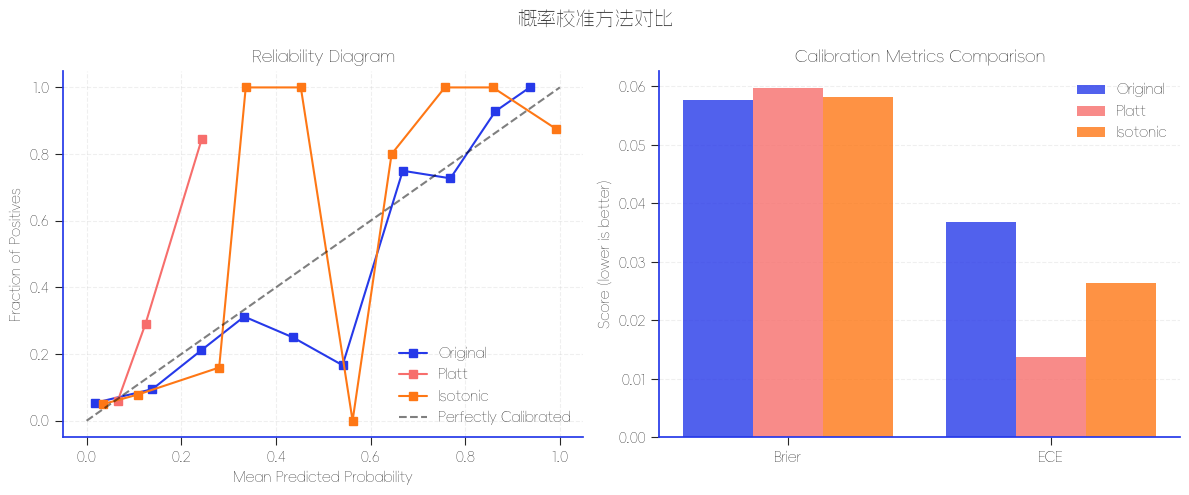

In [31]:
# 绘制校准对比图
print("绘制校准对比图...")

# 准备概率字典
proba_dict = {
    'Original': proba_orig,
    'Platt': proba_platt,
    'Isotonic': proba_iso
}

# 绘制对比图
fig = plot_calibration_comparison(y_test, proba_dict, title='概率校准方法对比')

Platt Scaling可靠性曲线:


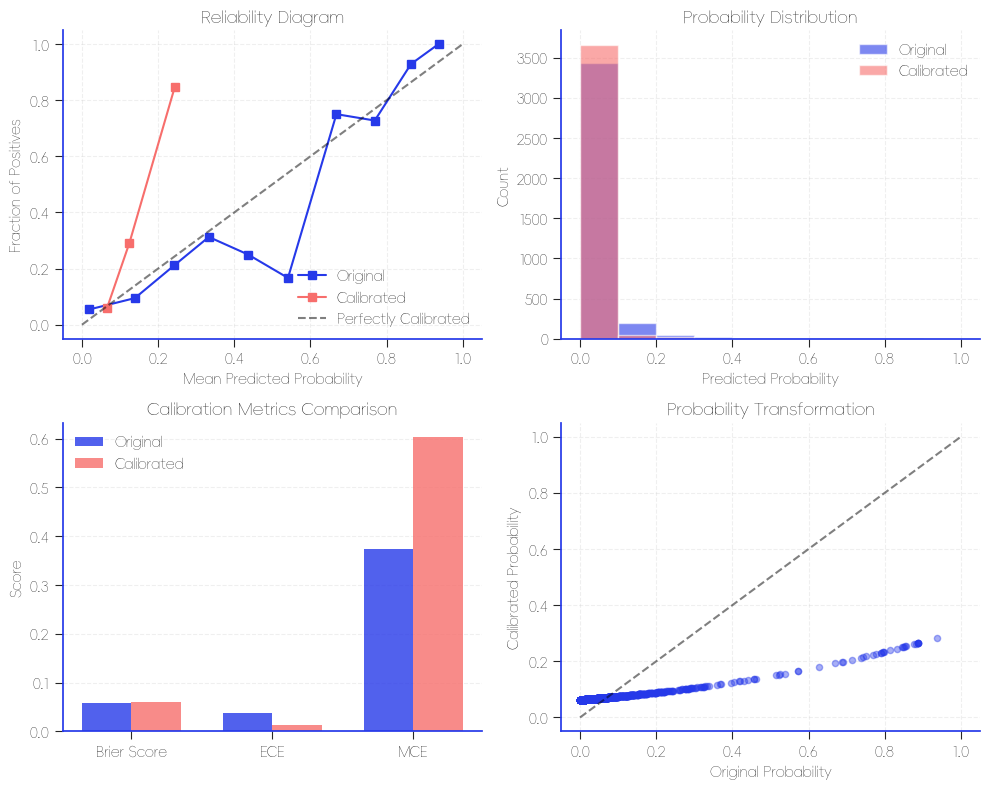

In [32]:
# 绘制可靠性曲线
print("Platt Scaling可靠性曲线:")
fig = calibrator_platt.plot_reliability_diagram(X_test, y_test)

## 9. 评分漂移校准 (Score Drift Calibration)

解决生产环境中模型评分分布与训练时不一致的问题。提供三种校准方法：
- **Linear**: 线性漂移校准（整体偏移/缩放）
- **Quantile**: 分位数对齐（分布变形）
- **Binning**: 分箱重校准（坏样本率变化）

In [33]:
from hscredit.core.models.score_drift import ScoreDriftCalibrator, plot_drift_comparison

print("=== 评分漂移校准演示 ===")

# 模拟生产环境数据（添加偏移和缩放）
np.random.seed(42)
# 模拟评分漂移：整体偏移+缩放
X_production = X_test.copy()
# 添加系统性偏移（模拟客群质量变化）
shift_factor = 0.1
scale_factor = 1.2

print(f"模拟生产环境数据漂移:")
print(f"  偏移系数: {shift_factor}")
print(f"  缩放系数: {scale_factor}")

=== 评分漂移校准演示 ===
模拟生产环境数据漂移:
  偏移系数: 0.1
  缩放系数: 1.2


In [34]:
# 使用线性漂移校准
drift_calibrator = ScoreDriftCalibrator(method='linear')
drift_calibrator.fit(base_model, X_production, X_reference=X_train_base)

print("\n线性漂移校准完成")

# 预测校准后的评分
scores_calib = drift_calibrator.predict_score(X_test)
scores_orig = base_model.predict_proba(X_test)[:, 1]

print(f"原始评分范围: [{scores_orig.min():.4f}, {scores_orig.max():.4f}]")
print(f"校准后评分范围: [{scores_calib.min():.4f}, {scores_calib.max():.4f}]")

线性校准参数: scale=2.0047, offset=-0.0152
参考分布: mean=0.0597, std=0.1774
当前分布: mean=0.0374, std=0.0885

线性漂移校准完成
原始评分范围: [0.0001, 0.9366]
校准后评分范围: [0.0001, 0.9499]


In [35]:
# 检测漂移
drift_report = drift_calibrator.detect_drift(X_train_base, X_production, metric='psi')

print("\n漂移检测报告:")
print(f"  检测指标: {drift_report['metric']}")
print(f"  PSI值: {drift_report['statistics']['psi']:.4f}")
print(f"  阈值: {drift_report['threshold']}")
print(f"  是否漂移: {drift_report['drift_detected']}")


漂移检测报告:
  检测指标: psi
  PSI值: 0.1432
  阈值: 0.25
  是否漂移: False



绘制漂移对比图...


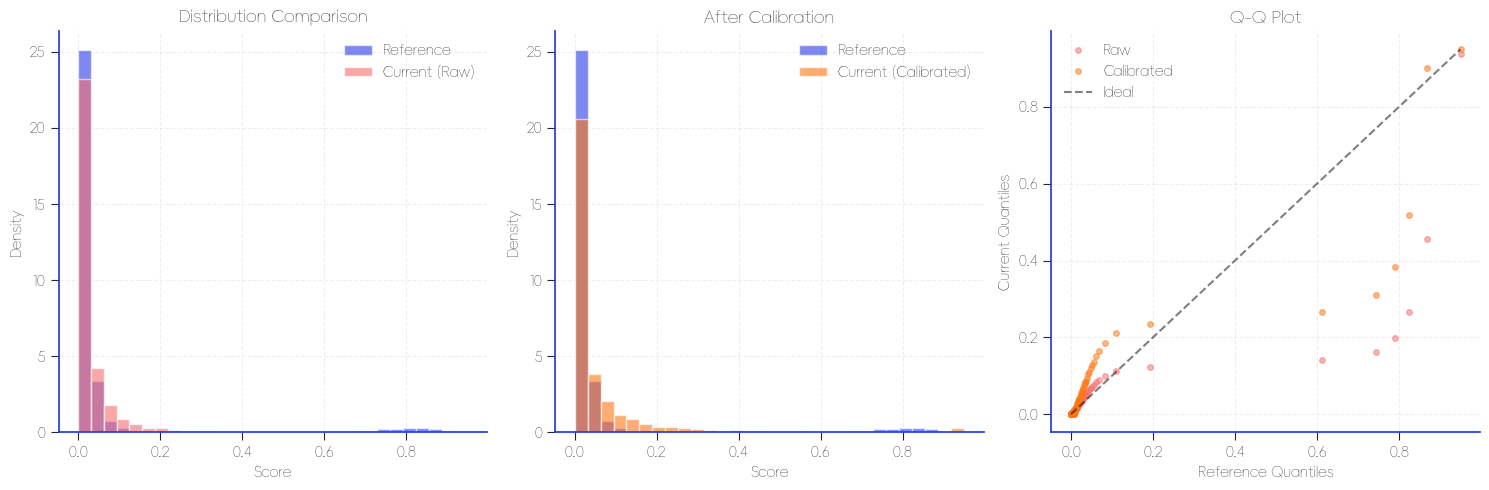

In [38]:
# 绘制漂移对比图
print("\n绘制漂移对比图...")
fig = plot_drift_comparison(drift_calibrator, X_train_base, X_production)

## 10. 概率评分转换 (Probability to Score)

将模型预测概率转换为标准评分。支持多种转换方法：
- **Standard**: 标准评分卡方法（基于log-odds）
- **Linear**: 线性映射
- **Quantile**: 分位数映射

支持两种评分方向：
- **Descending**: 概率越高分越低（信用分）
- **Ascending**: 概率越高分越高（欺诈分）

In [39]:
from hscredit.core.models.probability_to_score import ScoreTransformer, plot_score_transformation_curve, compare_score_transformers

print("=== 概率评分转换演示 ===")

# 信用评分转换（概率越高分越低）
credit_transformer = ScoreTransformer(
    method='standard',
    lower=300,
    upper=1000,
    direction='descending',  # 信用分
    base_odds=0.02,          # 基准好坏比 50:1
    base_score=600,          # 基准分
    pdo=20,                  # odds翻倍时分数变化
    precision=0
)

credit_transformer.fit(base_model, X_train)
credit_scores = credit_transformer.predict_score(X_test)

print("信用评分转换完成")
print(f"  评分范围: [{credit_scores.min():.0f}, {credit_scores.max():.0f}]")
print(f"  评分均值: {credit_scores.mean():.2f}")

=== 概率评分转换演示 ===


ValueError: y为None时，X必须是包含'target'列的DataFrame

In [ ]:
# 查看评分与逾期率对应关系
score_odds_ref = credit_transformer.score_odds_reference
print("\n评分与逾期率对应关系（前10行）:")
print(score_odds_ref.head(10).to_string(index=False))

In [ ]:
# 欺诈评分转换（概率越高分越高）
fraud_transformer = ScoreTransformer(
    method='linear',
    lower=0,
    upper=100,
    direction='ascending',  # 欺诈分
    precision=0
)

fraud_transformer.fit(base_model, X_train)
fraud_scores = fraud_transformer.predict_score(X_test)

print("欺诈评分转换完成")
print(f"  评分范围: [{fraud_scores.min():.0f}, {fraud_scores.max():.0f}]")
print(f"  评分均值: {fraud_scores.mean():.2f}")

In [ ]:
# 绘制概率-评分转换曲线
print("\n绘制转换曲线...")
fig = plot_score_transformation_curve(credit_transformer, title='信用评分转换曲线')

In [ ]:
# 对比多种转换方法
print("\n对比多种评分转换方法...")
fig = compare_score_transformers(
    base_model, 
    X_test,
    methods=['standard', 'linear', 'quantile'],
    lower=300,
    upper=1000,
    direction='descending'
)

In [ ]:
# 反向转换：评分转概率
proba_recovered = credit_transformer.inverse_transform(credit_scores)

print("反向转换验证:")
print(f"  原始概率均值: {base_model.predict_proba(X_test)[:, 1].mean():.4f}")
print(f"  恢复概率均值: {proba_recovered.mean():.4f}")
print(f"  平均绝对误差: {np.mean(np.abs(base_model.predict_proba(X_test)[:, 1] - proba_recovered)):.6f}")

## 11. 模型对比

对比所有模型的性能。

In [ ]:
# 模型对比 - 包含所有模型
model_results = pd.DataFrame({
    '模型': ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'ExtraTrees', 'GradientBoosting', '逻辑回归'],
    'AUC': [xgb_auc, lgb_auc, cat_auc, rf_auc, et_auc, gb_auc, lr_auc],
    'KS': [xgb_ks, lgb_ks, cat_ks, rf_ks, et_ks, gb_ks, lr_ks],
    'Gini': [xgb_gini, lgb_gini, cat_gini, rf_gini, et_gini, gb_gini, lr_gini]
})

model_results = model_results.sort_values('AUC', ascending=False)
print("模型性能对比:")
print(model_results.to_string(index=False))

## 8. 保存模型结果

将训练好的模型和结果保存到文件。

In [ ]:
from hscredit.utils import save_pickle
from hscredit.report.excel import ExcelWriter

# 保存模型
model_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/models'
os.makedirs(model_path, exist_ok=True)

save_pickle(xgb_model, os.path.join(model_path, 'xgb_model.pkl'))
save_pickle(lgb_model, os.path.join(model_path, 'lgb_model.pkl'))
save_pickle(cat_model, os.path.join(model_path, 'cat_model.pkl'))
save_pickle(rf_model, os.path.join(model_path, 'rf_model.pkl'))
save_pickle(et_model, os.path.join(model_path, 'et_model.pkl'))
save_pickle(gb_model, os.path.join(model_path, 'gb_model.pkl'))
save_pickle(lr_model, os.path.join(model_path, 'lr_model.pkl'))
save_pickle(scorecard, os.path.join(model_path, 'scorecard.pkl'))
save_pickle(binner, os.path.join(model_path, 'binner.pkl'))

# 保存结果到Excel - 使用hscredit的ExcelWriter和DataFrame.save()
output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/model_results.xlsx'

with ExcelWriter(theme_color='2639E9').set_filename(output_path) as writer:
    # 使用DataFrame.save()方法保存到worksheet
    model_results.save(writer, sheet_name='模型对比', title='模型性能对比', auto_width=True, condition_cols=['AUC', 'KS', 'Gini'])
    pd.DataFrame({'评分': scores_method1}).save(writer, sheet_name='评分分布', title='评分分布', auto_width=True)
    rules_df.save(writer, sheet_name='评分卡规则', title='评分卡规则明细', auto_width=True)
    # 保存校准和转换结果
    pd.DataFrame({
        '原始概率': proba_orig,
        'Platt校准': proba_platt,
        'Isotonic校准': proba_iso,
        '信用评分': credit_scores,
        '欺诈评分': fraud_scores
    }).save(writer, sheet_name='校准与评分', title='概率校准与评分转换结果', auto_width=True)

print(f"模型和结果已保存至: {model_path}")
print(f"Excel结果已保存至: {output_path}")

## 12. 总结

本notebook演示了hscredit模型模块的主要功能:

### 基础模型
1. **XGBoostRiskModel**: 高效梯度提升树，支持早停
2. **LightGBMRiskModel**: 快速梯度提升，适合大规模数据
3. **CatBoostRiskModel**: 对类别特征友好的提升树
4. **RandomForestRiskModel**: 随机森林模型
5. **ExtraTreesRiskModel**: 极端随机树模型
6. **GradientBoostingRiskModel**: sklearn梯度提升树
7. **LogisticRegression**: 扩展逻辑回归，支持统计信息
8. **ScoreCard**: 标准评分卡模型

### ScoreCard 新特性

ScoreCard 现已继承 `StandardScoreTransformer`，具备以下能力:

- **多方式评分计算**: `predict()` / `predict_score()` / `transform()`
- **反向转换**: `inverse_transform()` 将评分转回概率
- **灵活输入**: 支持 WOE 数据和原始数据输入
- **预训练模型**: 可直接传入训练好的LR模型，无需重新fit
- **完整评分卡功能**: 规则导出、特征重要性、评分分布分析等

### 概率校准 (calibration.py)

提供多种概率校准方法，改善模型预测概率的准确性:

- **ProbabilityCalibrator**: 统一校准接口
  - `method='platt'`: Sigmoid参数化校准（推荐）
  - `method='isotonic'`: 保序回归非参数校准
  - `method='beta'`: Beta分布校准
  - `method='histogram'`: 直方图分箱校准
- **plot_reliability_diagram()**: 绘制可靠性曲线
- **plot_calibration_comparison()**: 对比多种校准方法

### 评分漂移校准 (score_drift.py)

解决生产环境中评分分布与训练时不一致的问题:

- **ScoreDriftCalibrator**: 统一漂移校准接口
  - `method='linear'`: 线性漂移校准（整体偏移/缩放）
  - `method='quantile'`: 分位数对齐（分布变形）
  - `method='binning'`: 分箱重校准（坏样本率变化）
- **detect_drift()**: 检测评分漂移（PSI/KS/Wasserstein）
- **plot_drift_comparison()**: 绘制漂移对比图

### 概率评分转换 (probability_to_score.py)

将模型预测概率转换为标准评分:

- **ScoreTransformer**: 统一评分转换接口
  - `method='standard'`: 标准评分卡方法（基于log-odds）
  - `method='linear'`: 线性映射
  - `method='quantile'`: 分位数映射
- **评分方向**: `direction='descending'`（信用分）或 `'ascending'`（欺诈分）
- **score_odds_reference**: 评分与逾期率对应参照表
- **inverse_transform()**: 评分反向转概率
- **plot_score_transformation_curve()**: 绘制转换曲线
- **compare_score_transformers()**: 对比多种转换方法